# Load Dataset

In [1]:
import pandas as pd
df = pd.read_excel(
    
    "/Users/swarnalimollick/Downloads/_Projects/customer_churn_prediction/data/Telco_churn.xlsx"
)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# 2. Basic inspection
Check:
- shape 
- column names 



In [2]:
df.shape

(7043, 33)

In [3]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

# 3. Check duplicates


In [4]:
df.duplicated().sum()

np.int64(0)

# 4. Check missing values


In [5]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

# 5. Fix obvious data type issues


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

# 6. EDA
Analyze:
- churn count 
- churn by contract type 
- churn by payment method 
- churn by monthly charges 
- churn by tenure 


In [7]:
df["Churn Value"].value_counts()

# for the real real Customer Churn data, the dataset is generally imbalanced 
# because there are less number of customer who have the higher churn rate.
# Here, negative Churn rate is for 5174 customers and positive churn rate
# is for 1869 customers. 

Churn Value
0    5174
1    1869
Name: count, dtype: int64

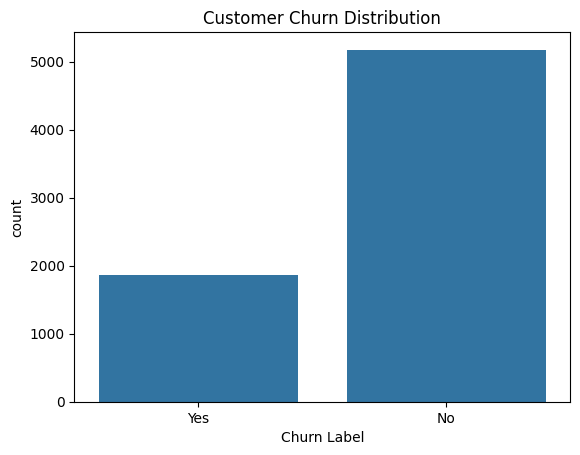

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x = "Churn Label", data = df)

plt.title("Customer Churn Distribution")
plt.show()

### Contract Type vs Churn

In [9]:
contract_type_percent = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_type_percent.round(2)

## customer using month-to-month contract type has 42.71% churn rate, and
## the lowest rate has for customers using Two year contract type

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


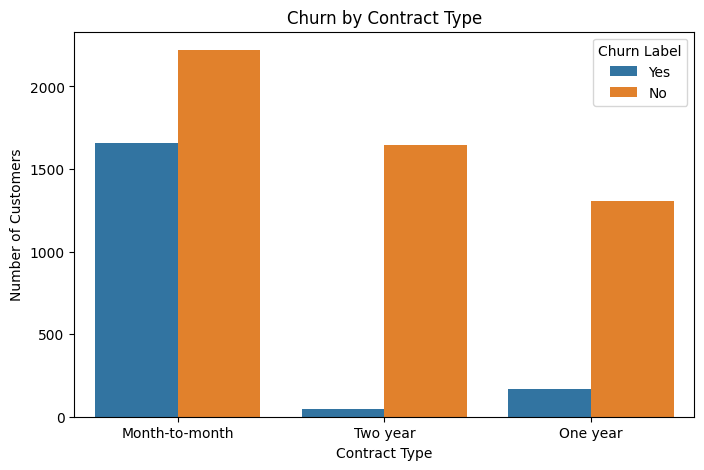

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

# Long-term contracts strongly reduce churn.
# Customers without a long-term commitment are much more likely to switch providers.

# Customers on Month-to-month contracts are the highest-risk group. Marketing 
# campaigns should focus on converting them to One-year or Two-year contracts 
# to improve customer retention.

### Payment Method vs Churn

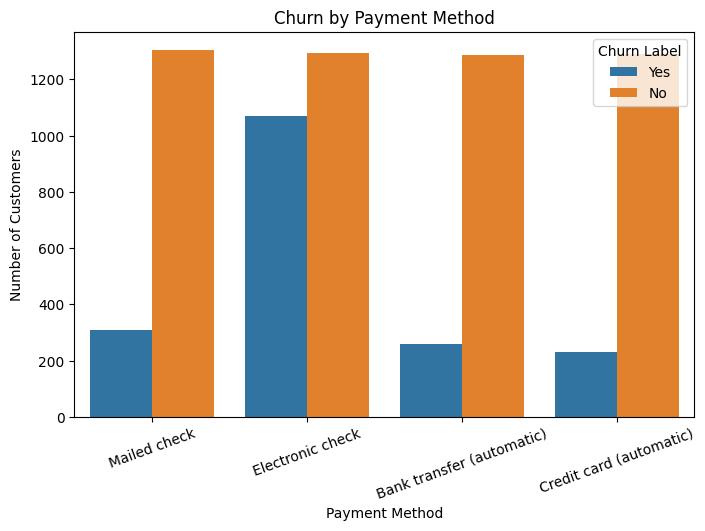

In [11]:
# •	churn by payment method 

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation = 20)
plt.show()

In [12]:
payment_churn_percent = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

payment_churn_percent.round(2)

# Customers using Electronic Check have a churn rate of 45.29%, 
# which is nearly three times higher than customers using automatic 
# payment methods such as Credit Card (15.24%) and Bank Transfer (16.71%).

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


### Churn vs Monthly Charges

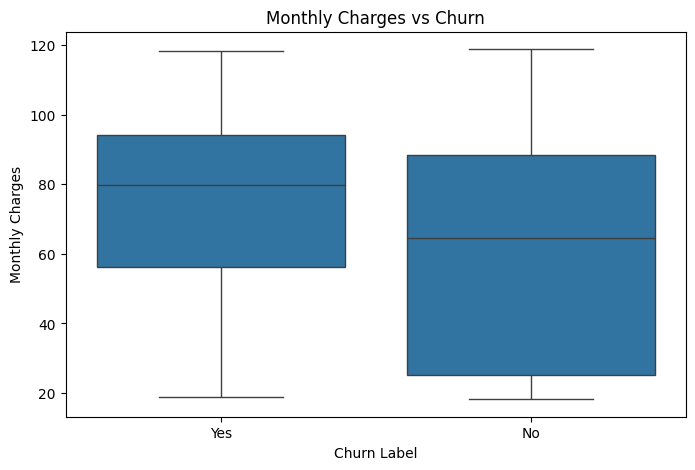

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

# Churn also depends on the monthly charges, if the monthly charge is
# high, the churn rate is also high and low churn rate comes from the 
# low monthly rate.

In [14]:
df.groupby("Churn Label")["Monthly Charges"].agg(["mean", "max", "min", "median"])

## the mean and median of the churn rate is higher, 74.44 and 79.66, respectively, 
## whereas for negative churn rate the values are much lower

,mean,max,min,median
Churn Label,,,,
No,61.265124,118.75,18.25,64.425
Yes,74.441332,118.35,18.85,79.650


In [15]:
df["MonthlyCharge_Bin"] = pd.cut(
    df["Monthly Charges"],
    bins=[0,30,60,90,120],
    labels=["0-30","30-60","60-90","90-120"]
)

monthly_charge_churn = pd.crosstab(
    df["MonthlyCharge_Bin"],
    df["Churn Label"],
    normalize="index"
) * 100

monthly_charge_churn.round(2)

## The highest churn rate can be seen when the monthly charge is between 60 and 90, 33.91%, and 
## the lowest churn rate is for the raneg 0 to 30, 9.80%.

Churn Label,No,Yes
MonthlyCharge_Bin,,
0-30,90.20,9.80
30-60,74.07,25.93
60-90,66.09,33.91
90-120,67.22,32.78


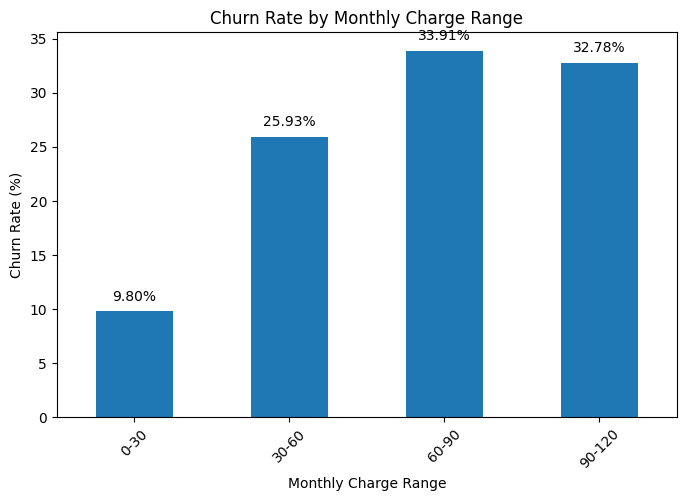

In [16]:
ax = monthly_charge_churn["Yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Monthly Charge Range")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Monthly Charge Range")
plt.xticks(rotation=45)

for i, value in enumerate(monthly_charge_churn["Yes"]):
    ax.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

Churn vs Tenure Months

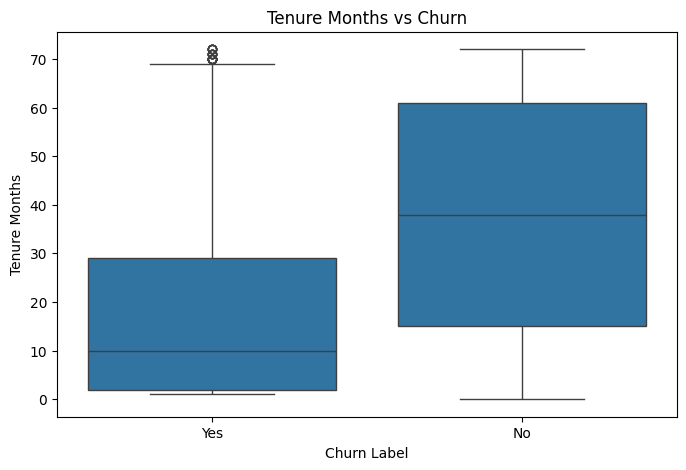

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Months vs Churn")
plt.show()

## Churned customer ususlly have low tenure and stayed customers have higher tenure.

In [18]:
df.groupby("Churn Label")["Tenure Months"].agg(["mean", "max", "min", "median"])

,mean,max,min,median
Churn Label,,,,
No,37.569965,72,0,38.0
Yes,17.979133,72,1,10.0


In [19]:
Tenure_Months_churn = pd.crosstab(
    df["Tenure Months"],
    df["Churn Label"],
    normalize="index"
) * 100

Tenure_Months_churn.round(2)

Churn Label,No,Yes
Tenure Months,,
0,100.00,0.00
1,38.01,61.99
2,48.32,51.68
3,53.00,47.00
4,52.84,47.16
...,...,...
68,91.00,9.00
69,91.58,8.42
70,90.76,9.24


### Online Security vs Churn Label

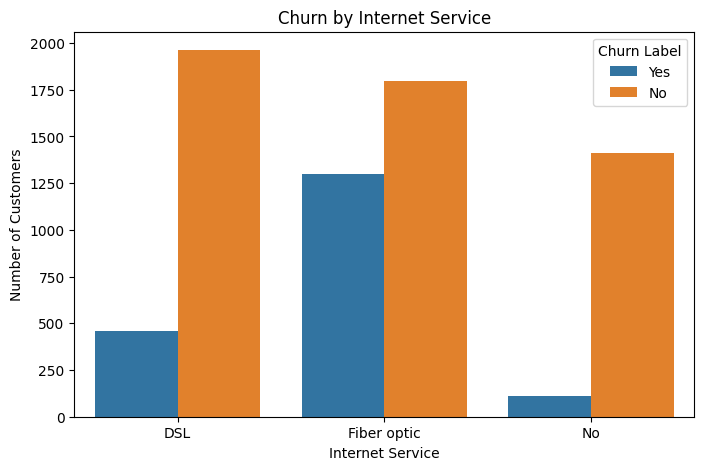

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()





# 7. Decide which columns to drop


In [21]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason', 'MonthlyCharge_Bin'],
      dtype='object')

In [22]:
print(df["Churn Reason"].value_counts())
print("\n")
print(df["Churn Label"].value_counts())
print("\n")
print(df["Contract"].value_counts())
print("\n")
print(df["Internet Service"].value_counts())
print("\n")


Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Long distance charges                         44
Lack of affordable download/upload speed      44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [23]:
cols_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Zip Code",
    "Lat Long",
    "Churn Reason",
    "Churn Score",
    "Churn Label"
]

df.drop(cols_to_drop, axis=1, inplace=True)

# 8. Handle missing values properly


In [24]:
df.isna().sum()

City                 0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
CLTV                 0
MonthlyCharge_Bin    0
dtype: int64

# 9. X/y separation


In [25]:
type(df)

pandas.core.frame.DataFrame

In [26]:
y = df["Churn Value"]
x = df.drop("Churn Value", axis=1)

In [27]:
print(df["Payment Method"].value_counts())
print("\n")
print(df["Tech Support"].value_counts())
print("\n")
print(df["Online Security"].value_counts())

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


Tech Support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


In [28]:
x.columns
x = x.drop("City", axis=1)
x.columns

Index(['Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges',
       'Total Charges', 'CLTV', 'MonthlyCharge_Bin'],
      dtype='object')

In [29]:
x = x.drop("MonthlyCharge_Bin", axis=1)

In [30]:
cate_cols = x.select_dtypes(include="object").columns
num_cols = x.select_dtypes(include=["int64", "float64"]).columns

print("cate_cols: ", cate_cols)
print("num_cols: ", num_cols)

cate_cols:  Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges'],
      dtype='object')
num_cols:  Index(['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'CLTV'], dtype='object')


In [31]:
y

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64

# 10. Train-test split


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
import sklearn
print(sklearn.__version__)

1.7.2


In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

x_train = x_train.copy()
x_test = x_test.copy()

In [35]:
print(x_train.shape)
print(x_test.shape)


(5634, 22)
(1409, 22)


## Preprocessing

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# convert categorical cols to string
x_train[cate_cols] = x_train[cate_cols].astype(str)
x_test[cate_cols] = x_test[cate_cols].astype(str)

preprocessor = ColumnTransformer([
    ("encode_text_columns", OneHotEncoder(handle_unknown="ignore"), cate_cols),
    ("num", "passthrough", num_cols)
])

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

# 12. Model training
# LoR

In [37]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression(max_iter=100)
lor.fit(x_train_processed, y_train)

/opt/anaconda3/envs/env_churn/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### predict

In [38]:
y_pred = lor.predict(x_test_processed)

#### evaluate

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8041163946061036

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


Confusion Matrix:
[[921 114]
 [162 212]]


In [40]:
y_prob = lor.predict_proba(x_test_processed)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8453589604484745


# Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators= 100,
    random_state=42
)
rf.fit(x_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### predict

In [42]:
rf_pred = rf.predict(x_test_processed)
rf_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [43]:
print(accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

0.7913413768630234
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

[[934 101]
 [193 181]]


### ROC-AUC

In [44]:
rf_prob = rf.predict_proba(x_test_processed)[:,1]

print(roc_auc_score(y_test, rf_prob))

0.8315766359244621


In [45]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
models = {
    "models": ["Logistic Regression", "Random Rorest"],
    "Accuracy":  [0.8041, 0.7913],
    "Recall": [recall_score(y_test, y_pred), recall_score(y_test, rf_pred)],
    "F1": [f1_score(y_test, y_pred), f1_score(y_test, rf_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob), roc_auc_score(y_test, rf_prob)]
}
print(models)

{'models': ['Logistic Regression', 'Random Rorest'], 'Accuracy': [0.8041, 0.7913], 'Recall': [0.5668449197860963, 0.4839572192513369], 'F1': [0.6057142857142858, 0.551829268292683], 'ROC-AUC': [0.8453589604484745, 0.8315766359244621]}


In [46]:
import pandas as pd

result_df = pd.DataFrame(models)
result_df

,models,Accuracy,Recall,F1,ROC-AUC
0,Logistic Regression,0.8041,0.566845,0.605714,0.845359
1,Random Rorest,0.7913,0.483957,0.551829,0.831577


# XGBOOST

In [47]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [48]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state = 42)

xgb.fit(x_train_processed, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### predict

In [49]:
xgb_pred = xgb.predict(x_test_processed)
xgb_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [50]:
xgb_prob = xgb.predict_proba(x_test_processed)[:,1]

print(roc_auc_score(y_test, rf_prob))

0.8315766359244621


In [51]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
models = {
    "models": ["Logistic Regression", "Random Rorest", "XGB"],
    "Accuracy":  [0.8041, 0.7913, accuracy_score(y_test, xgb_pred)],
    "Recall": [recall_score(y_test, y_pred), recall_score(y_test, rf_pred), recall_score(y_test, xgb_pred)],
    "F1": [f1_score(y_test, y_pred), f1_score(y_test, rf_pred), f1_score(y_test, xgb_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob), roc_auc_score(y_test, rf_prob), roc_auc_score(y_test, xgb_prob)]
}
print(models)

{'models': ['Logistic Regression', 'Random Rorest', 'XGB'], 'Accuracy': [0.8041, 0.7913, 0.7735982966643009], 'Recall': [0.5668449197860963, 0.4839572192513369, 0.4946524064171123], 'F1': [0.6057142857142858, 0.551829268292683, 0.5370101596516691], 'ROC-AUC': [0.8453589604484745, 0.8315766359244621, 0.8286212508718903]}


In [52]:
import pandas as pd

result_df = pd.DataFrame(models)
result_df

,models,Accuracy,Recall,F1,ROC-AUC
0,Logistic Regression,0.804100,0.566845,0.605714,0.845359
1,Random Rorest,0.791300,0.483957,0.551829,0.831577
2,XGB,0.773598,0.494652,0.537010,0.828621


Despite testing more complex models such as Random Forest and XGBoost, Logistic Regression achieved the best overall performance. This suggests that the relationship between customer attributes and churn is relatively linear and that the simpler model generalized better.

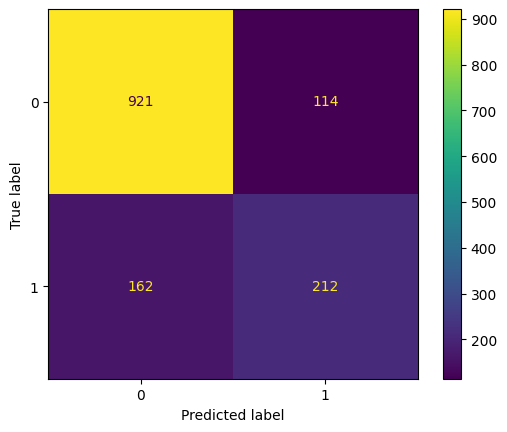

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    lor,
    x_test_processed,
    y_test
)

# Feature Importance

### Since Logistic Regression won:

In [54]:
feature_names = preprocessor.get_feature_names_out()


coef = lor.coef_[0]
coef

array([-1.32432332e-02,  1.16792485e-02, -1.49907057e-01, ...,
       -3.46316282e-02,  1.56257029e-02,  1.90389662e-05], shape=(5324,))

In [55]:
import pandas as pd
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

importance_df["Abs_Coefficient"] = importance_df["Coefficient"].abs()

importance_df = importance_df.sort_values(
    "Abs_Coefficient",
    ascending = False
)
importance_df.head(20)

,Feature,Coefficient,Abs_Coefficient
7,encode_text_columns__Dependents_Yes,-0.371083,0.371083
6,encode_text_columns__Dependents_No,0.369519,0.369519
25,encode_text_columns__Tech Support_No,0.305661,0.305661
34,encode_text_columns__Contract_Month-to-month,0.305457,0.305457
41,encode_text_columns__Payment Method_Electronic...,0.296035,0.296035
16,encode_text_columns__Online Security_No,0.293373,0.293373
27,encode_text_columns__Tech Support_Yes,-0.257884,0.257884
18,encode_text_columns__Online Security_Yes,-0.245596,0.245596
37,encode_text_columns__Paperless Billing_No,-0.232617,0.232617
38,encode_text_columns__Paperless Billing_Yes,0.231053,0.231053


## Key Findings from Logistic Regression
- Customers without dependents are more likely to churn.
- Lack of technical support is strongly associated with churn.
- Month-to-month contracts are a major churn driver.
- Electronic Check users exhibit elevated churn risk.
- Customers without online security services are more likely to leave.
- Two-year contracts significantly improve customer retention.

## Feature Importance Plot

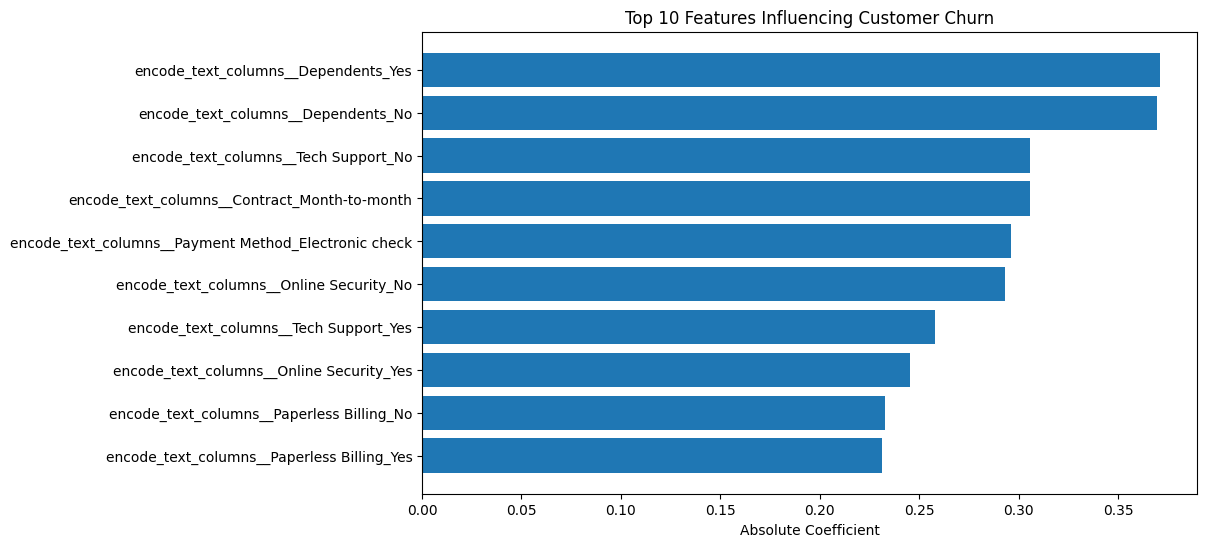

In [56]:
top_features = importance_df.head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Abs_Coefficient"]
)

plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Absolute Coefficient")

plt.gca().invert_yaxis()

plt.show()

### Save the model

In [59]:
import pickle

with open("churn_model.pkl", "wb") as f:
    pickle.dump(lor, f)

with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

### save the preprocessor:

In [ ]:
x_train.columns

In [60]:
for col in cate_cols:
    print(f"\n=== {col} ===")
    print(x_train[col].map(type).value_counts())


=== Gender ===
Gender
<class 'str'>    5634
Name: count, dtype: int64

=== Senior Citizen ===
Senior Citizen
<class 'str'>    5634
Name: count, dtype: int64

=== Partner ===
Partner
<class 'str'>    5634
Name: count, dtype: int64

=== Dependents ===
Dependents
<class 'str'>    5634
Name: count, dtype: int64

=== Phone Service ===
Phone Service
<class 'str'>    5634
Name: count, dtype: int64

=== Multiple Lines ===
Multiple Lines
<class 'str'>    5634
Name: count, dtype: int64

=== Internet Service ===
Internet Service
<class 'str'>    5634
Name: count, dtype: int64

=== Online Security ===
Online Security
<class 'str'>    5634
Name: count, dtype: int64

=== Online Backup ===
Online Backup
<class 'str'>    5634
Name: count, dtype: int64

=== Device Protection ===
Device Protection
<class 'str'>    5634
Name: count, dtype: int64

=== Tech Support ===
Tech Support
<class 'str'>    5634
Name: count, dtype: int64

=== Streaming TV ===
Streaming TV
<class 'str'>    5634
Name: count, dtype: 

In [61]:
for col in cate_cols:
    print(f"\n=== {col} ===")
    print(preprocessor.named_transformers_["encode_text_columns"].categories_)


=== Gender ===
[array(['Female', 'Male'], dtype=object), array(['No', 'Yes'], dtype=object), array(['No', 'Yes'], dtype=object), array(['No', 'Yes'], dtype=object), array(['No', 'Yes'], dtype=object), array(['No', 'No phone service', 'Yes'], dtype=object), array(['DSL', 'Fiber optic', 'No'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['Month-to-month', 'One year', 'Two year'], dtype=object), array(['No', 'Yes'], dtype=object), array(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'], dtype=object), array([' ', '100.2', '100.25', ..., '999.45', '999.8', '999.9'],
      shape=(5276,), dtype=object)]

=== Senior C

In [62]:
encoder = preprocessor.named_transformers_["encode_text_columns"]

for col, cats in zip(cate_cols, encoder.categories_):
    types = set(type(x) for x in cats)
    print(col, types)

Gender {<class 'str'>}
Senior Citizen {<class 'str'>}
Partner {<class 'str'>}
Dependents {<class 'str'>}
Phone Service {<class 'str'>}
Multiple Lines {<class 'str'>}
Internet Service {<class 'str'>}
Online Security {<class 'str'>}
Online Backup {<class 'str'>}
Device Protection {<class 'str'>}
Tech Support {<class 'str'>}
Streaming TV {<class 'str'>}
Streaming Movies {<class 'str'>}
Contract {<class 'str'>}
Paperless Billing {<class 'str'>}
Payment Method {<class 'str'>}
Total Charges {<class 'str'>}
